In [1]:
import pandas as pd
import numpy as np
import pymysql
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import pickle
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print(" XGBOOST - fraud_features")
print("="*60)

# =============================================
# 1. CONEXIÓN A MYSQL
# =============================================
print("\n Conectando a MySQL...")
conn = pymysql.connect(
    host='localhost', #host del servidor
    user='usr', #usuario del servidor 
    password='contraseña', #contraseña del servidor sql
    database='banco_aml',
    unix_socket='ruta', #ruta del socker
    autocommit=True,
    charset='char' #charset del servidor
)

# =============================================
# 2. CARGAR DATOS EN BLOQUES (CHUNKS)
# =============================================
print(" Cargando datos en bloques de 100,000 filas...")

# ===== COLUMNAS CON ONE-HOT ENCODING (14 features + target) =====
columnas = [
    'monto_alto', 'tipo_riesgoso', 'ratio_gasto_saldo',
    'saldo_cero', 'cambio_saldo', 'destino_saldo_cero',
    'monto_relativo', 'monto_riesgo_score',
    'es_PAYMENT', 'es_TRANSFER', 'es_CASH_OUT', 'es_CASH_IN', 'es_DEBIT',
    'es_transferencia_total',
    'isFraud'
]

query = f"SELECT {', '.join(columnas)} FROM fraud_features"

chunk_size = 100000
chunks = []
total_filas = 0

try:
    for chunk in pd.read_sql(query, conn, chunksize=chunk_size):
        chunks.append(chunk)
        total_filas += len(chunk)
        print(f"   Bloque cargado: {len(chunk):,} filas (total: {total_filas:,})")
    
    df = pd.concat(chunks, ignore_index=True)
    conn.close()
    print(f" Datos cargados: {len(df):,} filas")
    
except MemoryError:
    print(" Error de memoria: El dataset es demasiado grande para cargar completo.")
    print(" Solución alternativa: Usar Dask o entrenar en batches.")
    exit()

# =============================================
# 3. SEPARAR X e y
# =============================================
features = [
    'monto_alto', 'tipo_riesgoso', 'ratio_gasto_saldo',
    'saldo_cero', 'cambio_saldo', 'destino_saldo_cero',
    'monto_relativo', 'monto_riesgo_score',
    'es_PAYMENT', 'es_TRANSFER', 'es_CASH_OUT', 'es_CASH_IN', 'es_DEBIT',
    'es_transferencia_total'
]

X = df[features]
y = df['isFraud']

print(f"\n Features: {len(features)}")
print(f"   {', '.join(features)}")
print(f"Total transacciones: {len(X):,}")
print(f"Fraudes: {sum(y):,} ({sum(y)/len(y):.4%})")

# =============================================
# 4. DIVIDIR EN TRAIN/TEST
# =============================================
print("\n Dividiendo datos...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {len(X_train):,} transacciones")
print(f"Prueba: {len(X_test):,} transacciones")

# =============================================
# 5. ESCALAR
# =============================================
print("\n Escalando features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =============================================
# 6. ENTRENAR XGBOOST
# =============================================
print("\n Entrenando XGBoost...")

scale_pos = (len(y_train) - sum(y_train)) / sum(y_train)
print(f"scale_pos_weight: {scale_pos:.2f}")

model = xgb.XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    eval_metric='logloss',
    n_jobs=2
)

model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    verbose=False
)

print(" Modelo entrenado")

# =============================================
# 7. EVALUACIÓN
# =============================================
print("\n" + "="*60)
print(" EVALUACIÓN DEL MODELO")
print("="*60)

y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)

print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraude']))

print(f"\n ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Recall@1%
top_1_percent = int(0.01 * len(y_test))
top_indices = np.argsort(y_pred_proba)[-top_1_percent:]
recall_at_1 = np.sum(y_test.iloc[top_indices]) / np.sum(y_test)
print(f" RECALL@1%: {recall_at_1:.4f}")

# =============================================
# 8. IMPORTANCIA DE FEATURES
# =============================================
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n Importancia de features:")
for i, row in importance.iterrows():
    print(f"   {row['feature']}: {row['importance']:.4f}")

# =============================================
# 9. GUARDAR MODELO
# =============================================
print("\n Guardando modelo...")
with open('modelo_fraude_xgb.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('scaler_fraude.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(" Modelo guardado como 'modelo_fraude_xgb.pkl'")
print(" Escalador guardado como 'scaler_fraude.pkl'")

print("\n" + "="*60)
print(" ¡MODELO COMPLETADO CON es_transferencia_total!")
print("="*60)

/home/andr3s/anaconda3/envs/ML/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


 XGBOOST - fraud_features

 Conectando a MySQL...
 Cargando datos en bloques de 100,000 filas...
   Bloque cargado: 100,000 filas (total: 100,000)
   Bloque cargado: 100,000 filas (total: 200,000)
   Bloque cargado: 100,000 filas (total: 300,000)
   Bloque cargado: 100,000 filas (total: 400,000)
   Bloque cargado: 100,000 filas (total: 500,000)
   Bloque cargado: 100,000 filas (total: 600,000)
   Bloque cargado: 100,000 filas (total: 700,000)
   Bloque cargado: 100,000 filas (total: 800,000)
   Bloque cargado: 100,000 filas (total: 900,000)
   Bloque cargado: 100,000 filas (total: 1,000,000)
   Bloque cargado: 100,000 filas (total: 1,100,000)
   Bloque cargado: 100,000 filas (total: 1,200,000)
   Bloque cargado: 100,000 filas (total: 1,300,000)
   Bloque cargado: 100,000 filas (total: 1,400,000)
   Bloque cargado: 100,000 filas (total: 1,500,000)
   Bloque cargado: 100,000 filas (total: 1,600,000)
   Bloque cargado: 100,000 filas (total: 1,700,000)
   Bloque cargado: 100,000 filas (tot

 GENERANDO GRÁFICOS DE EVALUACIÓN - MODELO (CON TRANSFERENCIA TOTAL)

 Cargando modelo...
 Modelo y escalador cargados

 Cargando datos de prueba desde fraud_features...
 Datos de prueba cargados: 200,000 filas
   Features: 14
   Fraudes reales: 228 (0.1140%)


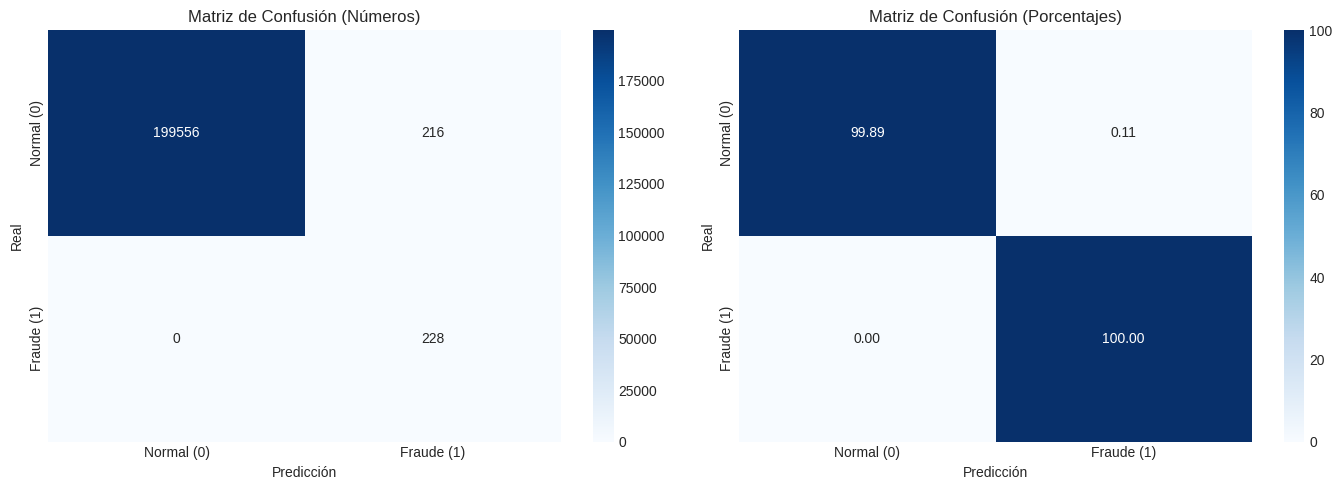

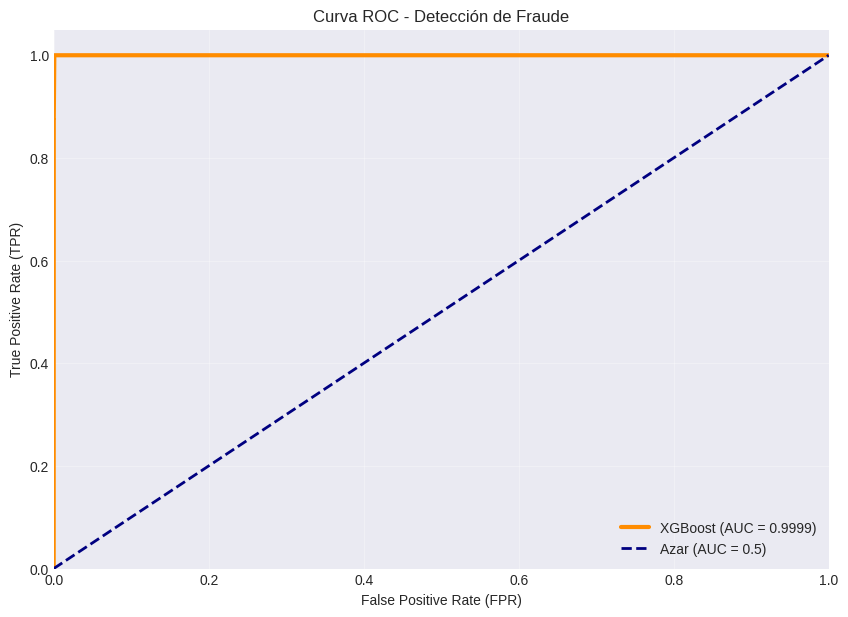

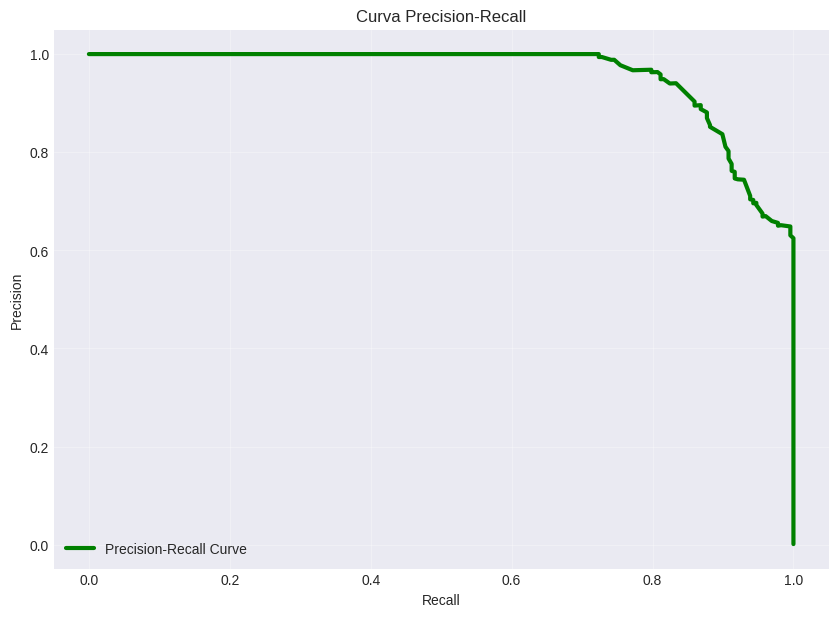

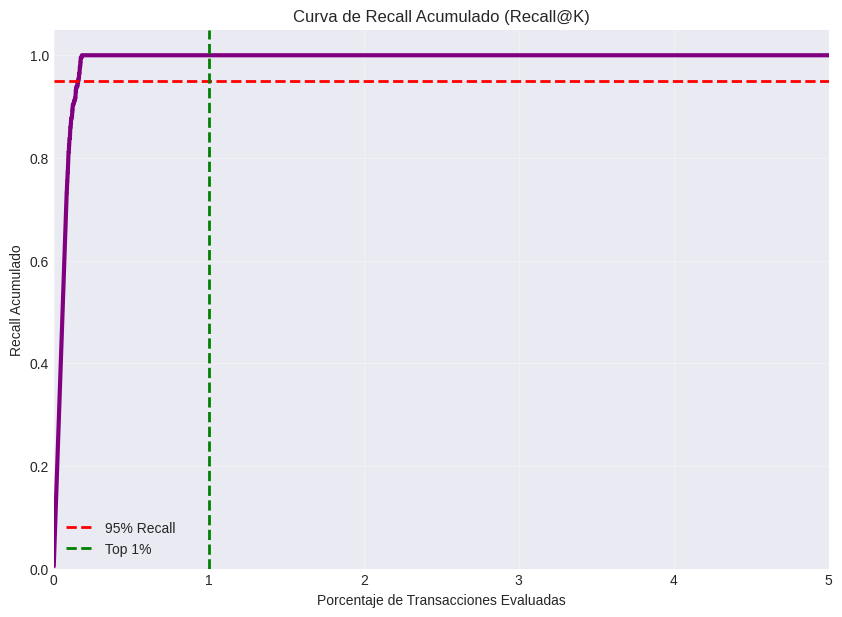


 MÉTRICAS DETALLADAS

 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    199772
      Fraude       0.51      1.00      0.68       228

    accuracy                           1.00    200000
   macro avg       0.76      1.00      0.84    200000
weighted avg       1.00      1.00      1.00    200000


 Métricas de Clasificación:
   Accuracy: 0.9989
   Precision: 0.5135
   Recall (Sensibilidad): 1.0000
   F1-Score: 0.6786
   Specificity: 0.9989
   ROC-AUC: 0.9999

 Matriz de Confusión (Interpretación):
   Verdaderos Positivos (TP): 228
   Falsos Positivos (FP): 216
   Falsos Negativos (FN): 0
   Verdaderos Negativos (TN): 199,556

 Umbral Óptimo (maximiza F1): 0.90
   F1-Score en umbral óptimo: 0.7367

 Métricas guardadas en 'metricas_modelo.txt'

 ¡GRÁFICOS GENERADOS CON ÉXITO!
   - matriz_confusion.png
   - curva_roc.png
   - curva_precision_recall.png
   - distribucion_probabilidades.png
   - curva_recall_k.png
 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, classification_report, accuracy_score, f1_score
import pickle
import pymysql
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print(" GENERANDO GRÁFICOS DE EVALUACIÓN - MODELO (CON TRANSFERENCIA TOTAL)")
print("="*60)

# =============================================
# 1. CARGAR MODELO Y DATOS DE PRUEBA
# =============================================
print("\n Cargando modelo...")

with open('modelo_fraude_xgb.pkl', 'rb') as f:
    model = pickle.load(f)
with open('scaler_fraude.pkl', 'rb') as f:
    scaler = pickle.load(f)

print(" Modelo y escalador cargados")

# =============================================
# 2. CARGAR DATOS DE PRUEBA 
# =============================================
print("\n Cargando datos de prueba desde fraud_features...")

conn = pymysql.connect(
    host='localhost', #host del servidor
    user='usr', #usuario del servidor 
    password='contraseña', #contraseña del servidor sql
    database='banco_aml',
    unix_socket='ruta', #ruta del socker
    autocommit=True,
    charset='char' #charset del servidor
)

# ===== COLUMNAS CON es_transferencia_total (14 features + target) =====
query = """
    SELECT 
        monto_alto, tipo_riesgoso, ratio_gasto_saldo,
        saldo_cero, cambio_saldo, destino_saldo_cero,
        monto_relativo, monto_riesgo_score,
        es_PAYMENT, es_TRANSFER, es_CASH_OUT, es_CASH_IN, es_DEBIT,
        es_transferencia_total,
        isFraud
    FROM fraud_features
    ORDER BY RAND()
    LIMIT 200000
"""
df_test = pd.read_sql(query, conn)
conn.close()

print(f" Datos de prueba cargados: {len(df_test):,} filas")

# =============================================
# 3. SEPARAR FEATURES Y TARGET
# =============================================
features = [
    'monto_alto', 'tipo_riesgoso', 'ratio_gasto_saldo',
    'saldo_cero', 'cambio_saldo', 'destino_saldo_cero',
    'monto_relativo', 'monto_riesgo_score',
    'es_PAYMENT', 'es_TRANSFER', 'es_CASH_OUT', 'es_CASH_IN', 'es_DEBIT',
    'es_transferencia_total'
]

X_test = df_test[features].values
y_test = df_test['isFraud'].values

print(f"   Features: {len(features)}")
print(f"   Fraudes reales: {sum(y_test):,} ({sum(y_test)/len(y_test)*100:.4f}%)")

# =============================================
# 4. ESCALAR Y PREDECIR
# =============================================
X_test_scaled = scaler.transform(X_test)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)

# =============================================
# 5. MATRIZ DE CONFUSIÓN
# =============================================
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (0)', 'Fraude (1)'],
            yticklabels=['Normal (0)', 'Fraude (1)'],
            ax=axes[0])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de Confusión (Números)')

cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Normal (0)', 'Fraude (1)'],
            yticklabels=['Normal (0)', 'Fraude (1)'],
            ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusión (Porcentajes)')

plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================
# 6. CURVA ROC
# =============================================
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'XGBoost (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC - Detección de Fraude')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig('curva_roc.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================
# 7. CURVA PRECISIÓN-RECALL
# =============================================
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 7))
plt.plot(recall, precision, color='green', lw=3, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.savefig('curva_precision_recall.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================
# 8. CURVA DE RECALL@K
# =============================================
sorted_indices = np.argsort(y_pred_proba)[::-1]
y_test_sorted = y_test[sorted_indices]

recall_acumulado = np.cumsum(y_test_sorted) / np.sum(y_test_sorted)
k_values = np.arange(1, len(y_test) + 1) / len(y_test) * 100

plt.figure(figsize=(10, 7))
plt.plot(k_values[:50000], recall_acumulado[:50000], color='purple', lw=3)
plt.xlabel('Porcentaje de Transacciones Evaluadas')
plt.ylabel('Recall Acumulado')
plt.title('Curva de Recall Acumulado (Recall@K)')
plt.axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='95% Recall')
plt.axvline(x=1, color='green', linestyle='--', linewidth=2, label='Top 1%')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 5)
plt.ylim(0, 1.05)
plt.savefig('curva_recall_k.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================
# 9. MÉTRICAS DETALLADAS
# =============================================
print("\n" + "="*60)
print(" MÉTRICAS DETALLADAS")
print("="*60)

print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraude']))

tn, fp, fn, tp = cm.ravel()
accuracy = accuracy_score(y_test, y_pred)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = f1_score(y_test, y_pred)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print("\n Métricas de Clasificación:")
print(f"   Accuracy: {accuracy:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall (Sensibilidad): {recall:.4f}")
print(f"   F1-Score: {f1:.4f}")
print(f"   Specificity: {specificity:.4f}")
print(f"   ROC-AUC: {roc_auc:.4f}")

print("\n Matriz de Confusión (Interpretación):")
print(f"   Verdaderos Positivos (TP): {tp:,}")
print(f"   Falsos Positivos (FP): {fp:,}")
print(f"   Falsos Negativos (FN): {fn:,}")
print(f"   Verdaderos Negativos (TN): {tn:,}")

# =============================================
# 10. DETECCIÓN DE OPTIMAL THRESHOLD
# =============================================
thresholds_opt = np.linspace(0.1, 0.9, 50)
f1_scores = []
for thresh in thresholds_opt:
    y_pred_temp = (y_pred_proba >= thresh).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_temp))

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds_opt[optimal_idx]
max_f1 = f1_scores[optimal_idx]

print(f"\n Umbral Óptimo (maximiza F1): {optimal_threshold:.2f}")
print(f"   F1-Score en umbral óptimo: {max_f1:.4f}")

# =============================================
# 11. GUARDAR MÉTRICAS
# =============================================
with open('metricas_modelo.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write(" MÉTRICAS DEL MODELO XGBOOST (CON TRANSFERENCIA TOTAL)\n")
    f.write("="*60 + "\n\n")
    f.write(f"ROC-AUC: {roc_auc:.4f}\n")
    f.write(f"Accuracy: {accuracy:.4f}\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall: {recall:.4f}\n")
    f.write(f"F1-Score: {f1:.4f}\n")
    f.write(f"Specificity: {specificity:.4f}\n\n")
    f.write(f"Matriz de Confusión:\n")
    f.write(f"  TP: {tp}\n")
    f.write(f"  FP: {fp}\n")
    f.write(f"  FN: {fn}\n")
    f.write(f"  TN: {tn}\n")
    f.write(f"Umbral óptimo: {optimal_threshold:.2f}\n")
    f.write(f"F1 en umbral óptimo: {max_f1:.4f}\n")

print("\n Métricas guardadas en 'metricas_modelo.txt'")

print("\n" + "="*60)
print(" ¡GRÁFICOS GENERADOS CON ÉXITO!")
print("   - matriz_confusion.png")
print("   - curva_roc.png")
print("   - curva_precision_recall.png")
print("   - distribucion_probabilidades.png")
print("   - curva_recall_k.png")
print("   - metricas_modelo.txt")
print("="*60)

# USO DE LLM PARA DATOS NUEVOS DE FRAUDE CON EL MODELO ENTRENADO (OLLAM)

In [3]:
import requests
import pickle
import numpy as np

# =============================================
# 1. CARGAR MODELO XGBOOST
# =============================================
with open('modelo_fraude_xgb.pkl', 'rb') as f:
    model = pickle.load(f)
with open('scaler_fraude.pkl', 'rb') as f:
    scaler = pickle.load(f)

print("Modelo y escalador cargados")

# =============================================
# 2. FUNCIÓN DE EXPLICACIÓN CON OLLAMA
# =============================================
def generar_explicacion(prompt):
    """
    Genera una explicación usando Llama 3 local (Ollama).
    """
    try:
        response = requests.post(
            "http://localhost:11434/api/generate",
            json={
                "model": "llama3.2",
                "prompt": prompt,
                "stream": False
            }
        )
        if response.status_code == 200:
            return response.json()["response"]
        else:
            return f" Error en Ollama: {response.status_code}"
    except Exception as e:
        return f" Error de conexión con Ollama: {e}"

# =============================================
# 3. FUNCIÓN DE PREDICCIÓN + EXPLICACIÓN
# =============================================
def predecir_y_explicar(amount, type_op, oldbalanceOrg, newbalanceOrig, oldbalanceDest):
    """
    Predice y genera una explicación para una transacción.
    """
    
    # ===== CONSTANTES =====
    MEDIANA_AMOUNT = 74871.94
    P95_AMOUNT = 518634.20
    P99_AMOUNT = 1615979.47
    
    # ===== CALCULAR FEATURES =====
    monto_alto = 1 if amount > P95_AMOUNT else 0
    tipo_riesgoso = 1 if type_op in ['TRANSFER', 'CASH_OUT'] else 0
    ratio_gasto_saldo = amount / oldbalanceOrg if oldbalanceOrg > 0 else 0
    saldo_cero = 1 if newbalanceOrig == 0 else 0
    cambio_saldo = oldbalanceOrg - newbalanceOrig
    destino_saldo_cero = 1 if oldbalanceDest == 0 else 0
    monto_relativo = amount / MEDIANA_AMOUNT
    
    if amount > P99_AMOUNT:
        monto_riesgo_score = 100
    elif amount > P95_AMOUNT:
        monto_riesgo_score = 75
    elif amount > MEDIANA_AMOUNT * 3:
        monto_riesgo_score = 50
    elif amount > MEDIANA_AMOUNT:
        monto_riesgo_score = 25
    else:
        monto_riesgo_score = 0
    
    # One-Hot Encoding
    es_PAYMENT = 1 if type_op == 'PAYMENT' else 0
    es_TRANSFER = 1 if type_op == 'TRANSFER' else 0
    es_CASH_OUT = 1 if type_op == 'CASH_OUT' else 0
    es_CASH_IN = 1 if type_op == 'CASH_IN' else 0
    es_DEBIT = 1 if type_op == 'DEBIT' else 0
    es_transferencia_total = 1 if (type_op == 'TRANSFER' and amount == oldbalanceOrg) else 0
    
    # ===== ARMAR FEATURES =====
    features = [
        monto_alto, tipo_riesgoso, ratio_gasto_saldo,
        saldo_cero, cambio_saldo, destino_saldo_cero,
        monto_relativo, monto_riesgo_score,
        es_PAYMENT, es_TRANSFER, es_CASH_OUT, es_CASH_IN, es_DEBIT,
        es_transferencia_total
    ]
    
    # ===== ESCALAR Y PREDECIR =====
    features_scaled = scaler.transform([features])
    probabilidad = float(model.predict_proba(features_scaled)[0, 1])
    fraude = probabilidad >= 0.5
    
    # ===== GENERAR EXPLICACIÓN =====
    if fraude:
        prompt = f"""
Eres un analista de fraude bancario. Explica por qué esta transacción fue marcada o no como fraudulenta.

DATOS:
- Monto: ${amount:,.2f}
- Tipo: {type_op}
- Saldo del origen antes: ${oldbalanceOrg:,.2f}
- Saldo del origen después: ${newbalanceOrig:,.2f}
- Saldo del destino antes: ${oldbalanceDest:,.2f}

FEATURES:
- monto_alto: {monto_alto} (1 = monto > $518,634)
- tipo_riesgoso: {tipo_riesgoso} (1 = TRANSFER o CASH_OUT)
- ratio_gasto_saldo: {ratio_gasto_saldo:.4f}
- saldo_cero: {saldo_cero} (1 = cuenta vaciada)
- cambio_saldo: ${cambio_saldo:,.2f}
- destino_saldo_cero: {destino_saldo_cero} (1 = destino vacío)
- monto_relativo: {monto_relativo:.4f} (vs mediana)
- monto_riesgo_score: {monto_riesgo_score} (0-100)
- es_transferencia_total: {es_transferencia_total} (1 = transfirió todo)

PROBABILIDAD DE FRAUDE: {probabilidad:.2%}

Genera un reporte ejecutivo en español (máximo 200 palabras) que incluya:
1. Análisis del caso
2. Señales de alerta
3. Recomendación para el equipo
4. Regulación aplicable (LFPIORPI o Circular 42/2015)
"""
        explicacion = generar_explicacion(prompt)
    else:
        explicacion = "✅ Transacción normal. No se requiere acción."
    
    return {
        'fraude': fraude,
        'probabilidad': probabilidad,
        'explicacion': explicacion,
        'features': {
            'monto_alto': monto_alto,
            'tipo_riesgoso': tipo_riesgoso,
            'ratio_gasto_saldo': round(ratio_gasto_saldo, 4),
            'saldo_cero': saldo_cero,
            'cambio_saldo': round(cambio_saldo, 2),
            'destino_saldo_cero': destino_saldo_cero,
            'monto_relativo': round(monto_relativo, 4),
            'monto_riesgo_score': monto_riesgo_score,
            'es_transferencia_total': es_transferencia_total
        }
    }

# =============================================
# 4. INTERFAZ INTERACTIVA POR CONSOLA
# =============================================
if __name__ == "__main__":
    print("\n" + "="*60)
    print(" SISTEMA DE DETECCIÓN DE FRAUDE - CONSULTA MANUAL")
    print("="*60)
    
    # ===== PEDIR DATOS AL USUARIO =====
    print("\n Ingresa los valores de la transacción:")
    print("-" * 40)
    
    try:
        amount = float(input("   Monto (amount): "))
        type_op = input("   Tipo (PAYMENT, TRANSFER, CASH_OUT, CASH_IN, DEBIT): ").strip().upper()
        oldbalanceOrg = float(input("   Saldo antes del origen (oldbalanceOrg): "))
        newbalanceOrig = float(input("   Saldo después del origen (newbalanceOrig): "))
        oldbalanceDest = float(input("   Saldo antes del destino (oldbalanceDest): "))
        
    except ValueError:
        print(" Error: Ingresa valores numéricos válidos.")
        exit()
    
    # ===== PREDECIR =====
    resultado = predecir_y_explicar(
        amount=amount,
        type_op=type_op,
        oldbalanceOrg=oldbalanceOrg,
        newbalanceOrig=newbalanceOrig,
        oldbalanceDest=oldbalanceDest
    )
    
    # ===== MOSTRAR RESULTADOS =====
    print("\n" + "="*60)
    print(" RESULTADO DE LA PREDICCIÓN")
    print("="*60)
    
    print(f"\n Features calculadas:")
    for key, value in resultado['features'].items():
        print(f"   {key}: {value}")
    
    print(f"\n PREDICCIÓN:")
    if resultado['fraude']:
        print(f"  ¡FRAUDE DETECTADO! Probabilidad: {resultado['probabilidad']:.4f} ({resultado['probabilidad']*100:.2f}%)")
    else:
        print(f" TRANSACCIÓN NORMAL. Probabilidad: {resultado['probabilidad']:.4f} ({resultado['probabilidad']*100:.2f}%)")
    
    print("\n EXPLICACIÓN:")
    print("="*60)
    print(resultado['explicacion'])
    print("="*60)

Modelo y escalador cargados

 SISTEMA DE DETECCIÓN DE FRAUDE - CONSULTA MANUAL

 Ingresa los valores de la transacción:
----------------------------------------


   Monto (amount):  500000
   Tipo (PAYMENT, TRANSFER, CASH_OUT, CASH_IN, DEBIT):  CASH_OUT
   Saldo antes del origen (oldbalanceOrg):  500000
   Saldo después del origen (newbalanceOrig):  0
   Saldo antes del destino (oldbalanceDest):  0



 RESULTADO DE LA PREDICCIÓN

 Features calculadas:
   monto_alto: 0
   tipo_riesgoso: 1
   ratio_gasto_saldo: 1.0
   saldo_cero: 1
   cambio_saldo: 500000.0
   destino_saldo_cero: 1
   monto_relativo: 6.6781
   monto_riesgo_score: 50
   es_transferencia_total: 0

 PREDICCIÓN:
  ¡FRAUDE DETECTADO! Probabilidad: 0.9995 (99.95%)

 EXPLICACIÓN:
**Reporte Ejecutivo: Transacción Sospechosa**

**Análisis del Caso**

La transacción en cuestión presenta un monto elevado de $500,000.00 y se realiza como una salida en efectivo (CASH_OUT), lo que puede indicar una actividad sospechosa. Además, el saldo del origen después de la transacción es de $0.00, lo que sugiere que se ha vaciado la cuenta.

**Señales de Alerta**

* El monto de la transacción es extremadamente alto y supera el límite establecido por la regulación.
* La transacción se realiza como una salida en efectivo, lo que puede indicar una intentona de ocultar la fuente de los fondos.
* El saldo del origen después de la transacción es de